In [ ]:
#menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/Kuliah/Semester 7/Machine Learning/Praktikum/praktikum mandiri/praktikum mandiri 06/data"

In [ ]:
#membaca file csv menggunakan pandas
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Kuliah/Semester 7/Machine Learning/Praktikum/praktikum mandiri/praktikum mandiri 06/data/UniversalBank.csv")
df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [ ]:
# 1. Import Library (lainnya)
# Machine learning & evaluasi
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # untuk plot 3D

# Utilitas
import numpy as np

In [ ]:
# 2. Informasi Ringkas & Statistik Deskriptif
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   Family              5000 non-null   int64  
 4   CCAvg               5000 non-null   float64
 5   Education           5000 non-null   int64  
 6   Mortgage            5000 non-null   int64  
 7   Personal Loan       5000 non-null   int64  
 8   Securities Account  5000 non-null   int64  
 9   CD Account          5000 non-null   int64  
 10  Online              5000 non-null   int64  
 11  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 468.9 KB


,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,45.338400,20.104600,73.774200,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,11.463166,11.467954,46.033729,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,23.000000,-3.000000,8.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,35.000000,10.000000,39.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,45.000000,20.000000,64.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,55.000000,30.000000,98.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,67.000000,43.000000,224.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [ ]:
# 3. Cek Target & Distribusi Kelas
target_col = 'Personal Loan'
print("Nilai unik target:", df[target_col].unique())
print("\nDistribusi kelas:\n", df[target_col].value_counts())

Nilai unik target: [0 1]

Distribusi kelas:
 Personal Loan
0    4520
1     480
Name: count, dtype: int64


In [ ]:
# 4. Pembersihan Ringan (sesuai kebutuhan dataset)
drop_cols = [c for c in ['ID','ZIP Code'] if c in df.columns]
df = df.drop(columns=drop_cols)

print("Missing values per kolom:\n", df.isna().sum())

Missing values per kolom:
 Age                   0
Experience            0
Income                0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64


In [ ]:
# 5. Normalisasi dan Split Data
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# 6. Pemilihan Fitur (X) & Label (y)
X = df.drop(columns=[target_col])  # fitur
y = df[target_col]                  # label/target
X.head(), y.head()

(   Age  Experience  Income  Family  CCAvg  Education  Mortgage  \
 0   25           1      49       4    1.6          1         0   
 1   45          19      34       3    1.5          1         0   
 2   39          15      11       1    1.0          1         0   
 3   35           9     100       1    2.7          2         0   
 4   35           8      45       4    1.0          2         0   
 
    Securities Account  CD Account  Online  CreditCard  
 0                   1           0       0           0  
 1                   1           0       0           0  
 2                   0           0       0           0  
 3                   0           0       0           0  
 4                   0           0       0           1  ,
 0    0
 1    0
 2    0
 3    0
 4    0
 Name: Personal Loan, dtype: int64)

In [ ]:
# 7. Split Data & Bangun Model SVM (kernel='linear')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = SVC(kernel='linear', random_state=42)
model.fit(X_train, y_train)
model

SVC(kernel='linear', random_state=42)

In [ ]:
# 8. Evaluasi Akurasi & Classification Report
y_pred = model.predict(X_test)
print(f"Akurasi: {accuracy_score(y_test, y_pred)*100:.2f}%\n")
print("Laporan Klasifikasi:\n", classification_report(y_test, y_pred, digits=4))

Akurasi: 95.70%

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0     0.9604    0.9934    0.9766       904
           1     0.9077    0.6146    0.7329        96

    accuracy                         0.9570      1000
   macro avg     0.9341    0.8040    0.8548      1000
weighted avg     0.9554    0.9570    0.9532      1000



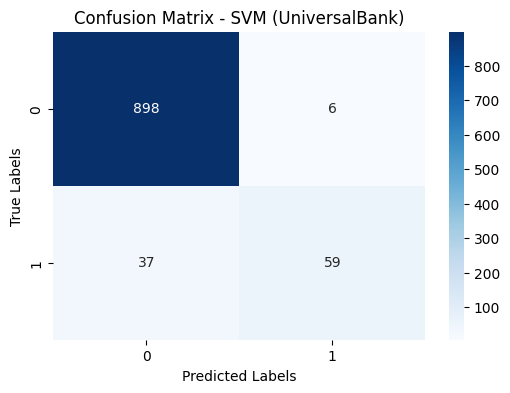

In [ ]:
# 9. Confusion Matrix (Heatmap)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVM (UniversalBank)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

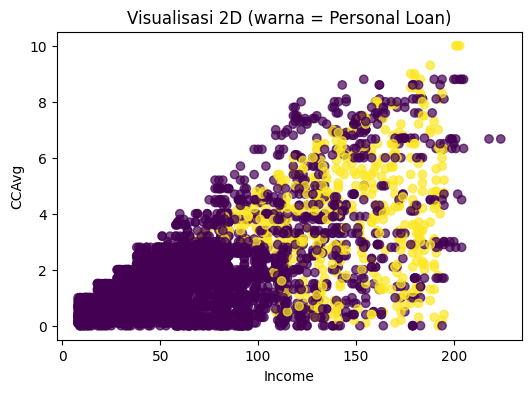

In [ ]:
# 10. Visualisasi 2D (Scatter)
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
vis2d = [c for c in ['Income','CCAvg'] if c in num_cols]
if len(vis2d) < 2:
    vis2d = num_cols[:2]

plt.figure(figsize=(6,4))
plt.scatter(df[vis2d[0]], df[vis2d[1]], c=df[target_col], alpha=0.7)
plt.xlabel(vis2d[0]); plt.ylabel(vis2d[1])
plt.title('Visualisasi 2D (warna = Personal Loan)')
plt.show()

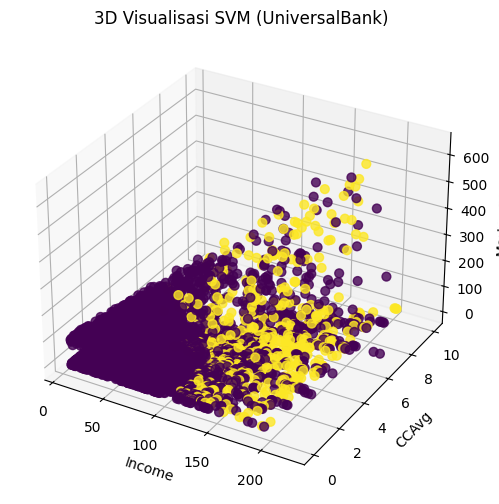

In [ ]:
# 11. 3D Visualisasi Hasil Model
# pilih 3 fitur untuk 3D (diprioritaskan Income, CCAvg, Mortgage jika tersedia)
candidates = [c for c in ['Income','CCAvg','Mortgage'] if c in num_cols]
if len(candidates) < 3:
    rest = [c for c in num_cols if c not in candidates]
    candidates += rest[:(3-len(candidates))]

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    df[candidates[0]], df[candidates[1]], df[candidates[2]],
    c=df[target_col], s=40, alpha=0.8
)
ax.set_xlabel(candidates[0]); ax.set_ylabel(candidates[1]); ax.set_zlabel(candidates[2])
ax.set_title('3D Visualisasi SVM (UniversalBank)')
plt.show()
